#Learn for them

https://www.youtube.com/shorts/iXcMZdnh66s

#Live Coding Session

Before starting today’s lesson, we will have a live coding session to review and reinforce the key concepts covered in our previous class.

In [ ]:
def longestCommonPrefix(strs) -> str:
        if not strs:
            return ""

        prefix = strs[0]
        print(prefix)

        for s in strs[1:]:
            while s[:len(prefix)] != prefix:
                prefix = prefix[:-1]
                if not prefix:
                    return ""

        return prefix

strs_1 = ["flower","flow","flight"]


strs_2 = ["dog","racecar","car"]

In [ ]:
longestCommonPrefix(strs_1)

flower


'fl'

#Python Class 12 – Iteration Protocols & Comprehensions

In the previous lessons, we explored the foundations of functions, argument passing, error handling, and recursion. With these tools, you are now able to build structured, modular, and safe programs. Today, we deepen that foundation by exploring a core idea that appears everywhere in Python: **iteration**.

Python does much more than simple looping. Behind every `for` loop, behind every comprehension, behind every file object and generator — there is an elegant internal system called the **iteration protocol**. Understanding this system transforms you from simply “using loops” into thinking like a true Python developer.

---

## What We Will Learn Today

### 1. The Iteration Protocol (The Engine Behind `for`)

Python’s `for` loop is just the surface. Underneath, it automatically calls two special tools:

* `iter()` — to get an iterator
* `next()` — to fetch elements one by one

This system lets Python loop over:

* lists
* sets
* dictionaries
* strings
* files
* and even your own custom objects

We will explore how this works and why understanding it matters.

---

### 2. List, Set, and Dictionary Comprehensions

Comprehensions are one of Python’s most powerful features, a shorter, faster, and more expressive alternative to writing loops manually.

You will learn how to build:

* list comprehensions
* set comprehensions
* dict comprehensions
* and how they relate to the iteration protocol

Comprehensions allow you to:

* filter data
* transform sequences
* write cleaner, more readable Pythonic code

---

### 3. Generator Expressions (A First Taste of Generators)

Before we study full generators in next classes, today we introduce their lightweight sibling:
**the generator expression**.

Generator expressions combine the logic of comprehensions with the memory efficiency of **lazy evaluation**, they produce values one at a time, only when needed.

---

## Why This Class Matters

Iteration and comprehensions are used constantly in:

* data processing
* machine learning pipelines
* reading large datasets
* filtering data
* writing cleaner algorithms
* performance optimization

Although these tools may look advanced, they become natural with practice, and they appear in almost every piece of real Python code written today.

#Iterations


we learned that the for loop can work on any sequence type in
Python, including lists, tuples, and strings, like this (with blank lines required by REPLs
after compound statements omitted for brevity):

In [ ]:
for x in [1, 2, 3, 4]:
    print(x ** 2, end=' ')

1 4 9 16 

As we’ve also learned, the for loop is even more generic than this—it works on any
iterable object. In fact, this is true of all iteration tools that scan objects from left to
right in Python, including for loops; comprehensions of all stripes; some in
membership tests; the zip, enumerate, and map built-in functions; and more. Any
iterable object will do, even nonsequences like dictionaries:

In [ ]:
for k in dict(a=1, b=2, c=3):
    print(k, end=' ')


a b c 

##The Iteration Protocol

One of the easiest ways to understand the iteration protocol is to see how it works with
a built-in type such as the file object

In [ ]:
with open('data.txt', 'w') as f:
    f.write("""Դու իմ գարնան առավոտ- ինչպե՞ս կանչեմ քեզ հիմա.
Դու հարազա՜տ, սրտիս մոտ - ինչպե՞ս կանչեմ քեզ հիմա:
Եվ դու, ոսկի իմ ամառ, հրանման, հրավառ,
Ամռան կեսօր դու իմ տոթ - ինչպե՞ս կանչեմ քեզ հիմա:""")


In [ ]:
print(open('data.txt').read())

Դու իմ գարնան առավոտ- ինչպե՞ս կանչեմ քեզ հիմա.
Դու հարազա՜տ, սրտիս մոտ - ինչպե՞ս կանչեմ քեզ հիմա:
Եվ դու, ոսկի իմ ամառ, հրանման, հրավառ,
Ամռան կեսօր դու իմ տոթ - ինչպե՞ս կանչեմ քեզ հիմա:


In [ ]:
open('data.txt').read()

'Դու իմ գարնան առավոտ- ինչպե՞ս կանչեմ քեզ հիմա.\nԴու հարազա՜տ, սրտիս մոտ - ինչպե՞ս կանչեմ քեզ հիմա:\nԵվ դու, ոսկի իմ ամառ, հրանման, հրավառ,\nԱմռան կեսօր դու իմ տոթ - ինչպե՞ս կանչեմ քեզ հիմա:'

Recall from our previous lectures that open file objects have a method called readline, which
reads one line of text from a file at a time—each time we call the readline method, we
advance to the next line. At the end of the file, an empty string is returned, which we can
detect to break out of a line-reading loop (remember, empty means false):

In [ ]:
f = open('data.txt')   # Read a three-line file in this directory
f.readline()           # readline loads one line on each call
f.readline()           # Newlines are \n everywhere in text mode
f.readline()           # Last lines may have a \n or not
f.readline()

'Ամռան կեսօր դու իմ տոթ - ինչպե՞ս կանչեմ քեզ հիմա:'

Returns empty string

In [ ]:
f.readline()           # Returns empty string at end-of-file

''

In [ ]:
f.readline()

''

Files, however, also have a method named `__next__` that has a nearly identical effect—
it returns the next line from a file each time it is called. The only noticeable difference
is that `__next__` raises a built-in StopIteration exception (that is, invokes a
signaling event) at end-of-file instead of returning an empty string:

In [ ]:
f = open('data.txt')   # __next__ loads one line on each call too
f.__next__()
f.__next__()
f.__next__()
f.__next__()

'Ամռան կեսօր դու իմ տոթ - ինչպե՞ս կանչեմ քեզ հիմա:'

What will happen?

In [ ]:
f.__next__() # but this raises an exception at end-of-file

StopIteration: 

And this interface is most of what we call the iteration protocol in Python. Any object
with a `__next__` method to advance to a next result, which raises StopIteration at
the end of the series of results, is considered an iterator in Python. Any such object may
also be stepped through with a for loop or any other iteration tool, because all iteration
tools normally work internally by calling `__next__` on each iteration and catching the
StopIteration exception to know when to exit. As you’ll see in a moment, for some
objects the full protocol includes an additional first step to call iter, but this isn’t
required for files.


The file object’s iterator will do the work of automatically loading lines as you go, both
one at a time and efficiently. The following, for example, reads line by line, printing the
uppercase version of each line along the way—without ever explicitly reading from the
file at all:

In [ ]:
for line in open('data.txt'):    # Use file iterators to read by lines
    print(line.upper(), end='')  # Calls __next__, catches StopIteration

ԴՈՒ ԻՄ ԳԱՐՆԱՆ ԱՌԱՎՈՏ- ԻՆՉՊԵ՞Ս ԿԱՆՉԵՄ ՔԵԶ ՀԻՄԱ.
ԴՈՒ ՀԱՐԱԶԱ՜Տ, ՍՐՏԻՍ ՄՈՏ - ԻՆՉՊԵ՞Ս ԿԱՆՉԵՄ ՔԵԶ ՀԻՄԱ:
ԵՎ ԴՈՒ, ՈՍԿԻ ԻՄ ԱՄԱՌ, ՀՐԱՆՄԱՆ, ՀՐԱՎԱՌ,
ԱՄՌԱՆ ԿԵՍՕՐ ԴՈՒ ԻՄ ՏՈԹ - ԻՆՉՊԵ՞Ս ԿԱՆՉԵՄ ՔԵԶ ՀԻՄԱ:

##What happens behind the scenes when you write `for x in object:`?

Python does NOT magically loop through objects.
It calls two built-in functions:

✔ iter(obj)

Creates an iterator from any iterable.

✔ next(iterator)

Fetches the next item.
Stops when it hits the end, raising StopIteration.

##What is an Iterable?

An **iterable** is any object that can produce an iterator via `iter()`.

| Type           | Examples                     |
| -------------- | ---------------------------- |
| Sequence       | list, tuple, string          |
| Non-sequence   | dict, set                    |
| Files          | the file object is iterable  |
| Custom classes | if they implement `__iter__` |


In [ ]:
class Rafo():
    def __init__(self, data):
        pass
list('afijund')

##What is an Iterator?

An iterator is an object with:

__iter__() → returns itself

__next__() → returns next element (or raises StopIteration)

💡 Every iterator is iterable,
but not every iterable is an iterator.

#How a `for` Loop Actually Works

####Manual iteration

Although Python iteration tools call these functions automatically, we can also use them
to apply the iteration protocol manually when needed. The following demonstrates the
equivalence between automatic and manual iteration (again, for runs the internal
equivalent of I.__next__ instead of the next(I) used here, but the effect is the same):

Your `for` loop:

In [ ]:
data = [1, 2, 3, 4, 5]
for x in data:
    print(x)

1
2
3
4
5


Python internally does:

In [ ]:
it = iter(data) # Manual iteration: what for loops usually do
while True:     # Use try statements to catch stop exception
    try:
        x = next(it)
    except StopIteration:
        break
    print(x)

1
2
3
4
5


In [ ]:
type(it)

list_iterator

##The iter and next built-ins
To simplify manual iteration code, Python also provides a built-in function, next, that
has the same net effect as calling an object’s `__next__` method. That is, given an
iterator object `X`, the call `next(X)` is the same as `X.__next__()`, but is noticeably
simpler to type and read (and actually runs slightly faster in CPython 3.12 for tested
cases). With files, for instance, either form may be used:

In [ ]:
f = open('data.txt')
f.__next__()   # Call iteration method directly

'Դու իմ գարնան առավոտ- ինչպե՞ս կանչեմ քեզ հիմա.\n'

In [ ]:
next(f)        # next(f) is the same as f.__next__()


'Դու հարազա՜տ, սրտիս մոտ - ինչպե՞ս կանչեմ քեզ հիմա:\n'

Technically, there is one more piece to the iteration protocol alluded to earlier. When
the for loop begins, it first obtains an iterator from an iterable object, by calling the
iterable’s `__iter__` method. The object returned by this call in turn has the required
`__next__` method to advance. For convenience again, the iter built-in function
internally runs the equivalent of the `__iter__` method, much as next runs the equivalent
of `__next__`.
Hence, for loops run the internal equivalent of the following, though the iter step is
moot and optional for files—they are their own iterators, because files don’t support
multiple scans per open:


In [ ]:
f = open('data.txt')
I = iter(f) # Fetch an iterator from an iterable
next(I) # Fetch the next result from the iterator

'Դու իմ գարնան առավոտ- ինչպե՞ս կանչեմ քեզ հիմա.\n'

In [ ]:
next(I) # Files iterables are iterators themselves

'Դու հարազա՜տ, սրտիս մոտ - ինչպե՞ս կանչեմ քեզ հիմա:\n'

##The full iteration protocol


With all these pieces in place, Figure sketches this full iteration protocol, used by
every iteration tool in Python and supported by a wide variety of object types. It’s based
on two objects used in two distinct steps by iteration tools:

* The iterable object for which iteration is requested. Calling this object’s
`__iter__` returns an iterator, and is the same as calling iter.

* The iterator object returned by the iterable. Calling this object’s `__next__`
produces results during the iteration and raises StopIteration when no more
results remain, and is the same as calling next.


The iteration protocol, used by for loops, comprehensions, maps, and more:

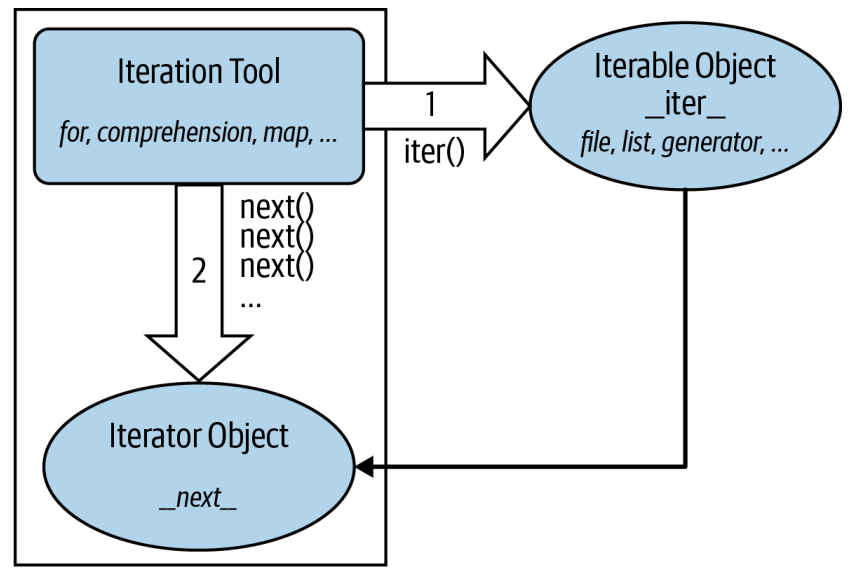

These steps are orchestrated automatically by iteration tools in most cases, but it helps
to understand these two objects’ roles. For example, in some cases these two objects
are the same when only a single scan is supported (e.g., files), and the iterator object is
often a temporary, used internally by the iteration tool.


##Iterables vs Iterators (Key Distinction)

| Concept                   | Iterable              | Iterator           |
| ------------------------- | --------------------- | ------------------ |
| Can call `iter(obj)`?     | Yes                   | Yes                |
| Has `__next__()`?         | No                    | Yes                |
| Produces elements lazily? | No                    | Yes                |
| Can be reused?            | Yes (multiple passes) | No (consumed once) |


In [ ]:
lst = [10, 20, 30]
it = iter(lst)

print(next(it))  # 10
print(next(it))  # 20
print(next(it))  # 30


10
20
30


In [ ]:
next(it)  # StopIteration !

StopIteration: 

Creating Our Own Iterator Class. We will study the OOP in our next lectures.

In [ ]:
class Countdown:
    def __init__(self, start):
        self.current = start

    def __iter__(self):
        return self

    def __next__(self):
        if self.current <= 0:
            raise StopIteration
        self.current -= 1
        return self.current + 4


In [ ]:
for x in Countdown(5):
    print(x)

8
7
6
5
4


#Comprehensions

##Comprehensions = compact syntax for mapping, filtering, and transforming data.

Now that we’ve seen how the iteration protocol works, let’s turn to one of its most
common use cases. Together with for loops, list comprehensions are one of the most
prominent contexts in which the iteration protocol is applied.
In the previous lectures, we learned how to use range to change a list as we step across
it:


In [ ]:
L = [1, 2, 3, 4, 5]
for i in range(len(L)):
    L[i] += 10
L

[11, 12, 13, 14, 15]

This works, but as mentioned there, it may not be the optimal “best practice” approach
in Python. Today, the list comprehension expression makes many such prior coding
patterns obsolete. Here, for example, we can replace the loop with a single expression
that produces the desired result list:

In [ ]:
L = [x + 10 for x in L]
L

[31, 32, 33, 34, 35]

The net result is similar, but it requires less coding on our part and is likely to run
substantially faster—in fact, it’s often twice as fast as tested in CPython 3.12. The list
comprehension isn’t exactly the same as the for loop statement version because it
makes a new list object, which might matter if there are multiple references to the
original list, but it’s close enough for most applications and is a common and convenient
enough approach to merit a closer look here.

##List Comprehension Basics

Basic pattern:

    [new_value for item in iterable]

Add filtering:

    [new_value for item in iterable if condition]    

In [ ]:
squares = [x*x for x in range(6)]
evens = [x for x in range(2, 10) if x % 2 == 0] # we can use if also in list comprehension

print("List of squares: ", squares, end = '\n\n')
print("List of evens: ", evens)

List of squares:  [0, 1, 4, 9, 16, 25]

List of evens:  [2, 4, 6, 8]


As one particularly useful extension, the `for` loop nested in a comprehension expression
can have an associated `if` clause to filter out of the result items for which the test is not
true. (It’s really a filter in, but it works out the same.)

### Which one is faster?

Using a for loop

In [ ]:
#%%timeit
%%time
squared_list_for = []
for x in range(10):
    squared_list_for.append(x*x)

CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 11.2 µs


Using a list comprehension

In [ ]:
#%%timeit
%%time
squared_list_comp = [x*x for x in range(10)]

CPU times: user 6 µs, sys: 1e+03 ns, total: 7 µs
Wall time: 7.87 µs


However, list comprehensions are more concise to write, and widely useful in Python
programs because building result lists is such a common task. Moreover, depending on
your Python and code, list comprehensions might run much faster than manual for loop
statements (often 2X as stated earlier) because their iterations are performed at the
speed of optimized (and usually compiled) code inside the interpreter, rather than with
manual Python code. Especially for larger data sets, there is often a major performance
advantage to using this expression.


##Set Comprehensions

In [ ]:
unique_lengths = {len(word) for word in ["Եղիշե", "Չարենց", "Անքուն", "Գիշերին"]}
unique_lengths

{5, 6, 7}

##Dictionary Comprehensions

In [ ]:
lines = ["Քնել չի լինում...", "Հիմա, երբ այնպես ուզում եմ քնել,", \
         "Ամե՛ն, ամե՛ն ինչ մտքիցս հանել:", 'Հայացքներս՝ անփակ՝ թափառում են լուռ —']
lengths = {l: len(l) for l in lines}
lengths

{'Քնել չի լինում...': 17,
 'Հիմա, երբ այնպես ուզում եմ քնել,': 32,
 'Ամե՛ն, ամե՛ն ինչ մտքիցս հանել:': 30,
 'Հայացքներս՝ անփակ՝ թափառում են լուռ —': 37}

##Generator Expressions (Lazy Comprehensions)

List comprehension creates a full list in memory.

Generator expression creates a lazy iterator.

List comprehension:

In [ ]:
L = [x*x for x in range(10)]
L

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

Generator expression:


In [ ]:
G = (x*x for x in range(10))
G

<generator object <genexpr> at 0x7da89b8ad220>

In [ ]:
for val in G:
    print(val)

0
1
4
9
16
25
36
49
64
81


After this loop G is **exhausted**.

###Differences:

| List               | Generator          |
| ------------------ | ------------------ |
| Stores all results | Produces on demand |
| Uses more RAM      | Memory-efficient   |
| Fast access        | One-time use       |


##Why This Matters in Real Projects

Iteration and comprehensions appear everywhere:

✔ Reading large files

Generators avoid loading everything at once.

✔ Machine learning preprocessing pipelines

Clean, filter, map data.

✔ Data pipelines / ETL

Stream data efficiently.

✔ Writing Pythonic algorithms

Cleaner, faster, more expressive.

#Why list/set/dict comprehensions are faster than for loops?

Comprehensions are faster for three main reasons:

##Reason 1 — Comprehensions run at C-speed (inside Python’s interpreter)

A normal for loop executes Python bytecode step by step:

In [ ]:
result = []
for x in range(10):
    result.append(x*x)
result

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

This involves:

* creating loop variables

* calling `append()` many times

* executing Python instructions one-by-one

* updating references

This overhead is large.

But a comprehension:

In [ ]:
result = [x*x for x in range(10)]
result

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

is optimized internally:

* fewer Python-level operations

* most work is done by fast C-level loops inside CPython

* no repeated method lookups (`append`)

* no repeated attribute access

##Reason 2 — Comprehensions avoid extra function calls

Consider the loop:

    L.append(x*x)


That means:

* load L

* load `.append` attribute

* call function object

* allocate result

In a list comprehension, Python does all of this internally in a tight, optimized loop.


##Reason 3 — Comprehensions know the final container size

For a list, Python can often preallocate memory more efficiently.

This reduces memory growth operations.


**Conclusion**

Comprehensions are:

* cleaner syntax

* fewer Python instructions

* faster execution because they run in C

* optimized memory usage

That’s why real Python developers use them everywhere.

#Why is this a generator expression?

In [ ]:
[1, 2, 3, 4]
[x for x in range(10)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
G = (x*x for x in range(10))
G

<generator object <genexpr> at 0x7da89b8acfb0>

This is called a generator expression.

A generator expression looks like a comprehension, but:

| Expression         | Result                               |
| ------------------ | ------------------------------------ |
| `[ ... ]`          | creates a **list**                   |
| `{ ... }`          | creates a **set**                    |
| `{key: value ...}` | creates a **dict**                   |
| `( ... )`          | creates a **generator**, NOT a tuple |


How it works:

* It returns a generator `object`, not evaluated yet.

* Values are produced only when you call `next()`.

In [ ]:
G = (x*x for x in range(5))
next(G)   # 0
next(G)   # 1
next(G)   # 4

4

A generator expression is basically syntactic sugar for:

In [ ]:
def _gen():
    for x in range(10):
        yield x*x
G = _gen()

Why no tuple comprehensions?

Because tuple syntax is ambiguous.

For example:

In [ ]:
t = (1, 2, 3)             # tuple
G = (x*x for x in data)   # generator

print(type(t), end = '\n\n')
print(type(G))

<class 'tuple'>

<class 'generator'>


Python would not be able to tell:

Should `(x*x for x in data)` be a `tuple` or a `generator`?


Also a `tuple` must know all elements in advance.

`Tuples` are **immutable**, they cannot be filled gradually.

But a generator produces values lazily, one at a time.

You cannot build an **immutable** container incrementally.

✔ But if you WANT a `tuple` from a `generator`

You explicitly wrap it:

In [ ]:
t = tuple(x*x for x in range(10))

print(type(t), end = '\n\n')
print(t)

<class 'tuple'>

(0, 1, 4, 9, 16, 25, 36, 49, 64, 81)


This gives you a tuple, but it’s not `tuple comprehension`; it’s:

A generator expression

Passed to `tuple()`

#Comparing Bytecode: List Comprehension vs For Loop

In [ ]:
import dis

# 1. List Comprehension
def list_comp():
    return [x * x for x in range(5)]


# 2. For Loop Version
def for_loop():
    result = []
    for x in range(5):
        result.append(x * x)
    return result

In [ ]:
print("Bytecode: LIST COMPREHENSION")
dis.dis(list_comp)

Bytecode: LIST COMPREHENSION
  4           0 RESUME                   0

  5           2 LOAD_GLOBAL              1 (NULL + range)
             12 LOAD_CONST               1 (5)
             14 CALL                     1
             22 GET_ITER
             24 LOAD_FAST_AND_CLEAR      0 (x)
             26 SWAP                     2
             28 BUILD_LIST               0
             30 SWAP                     2
        >>   32 FOR_ITER                 7 (to 50)
             36 STORE_FAST               0 (x)
             38 LOAD_FAST                0 (x)
             40 LOAD_FAST                0 (x)
             42 BINARY_OP                5 (*)
             46 LIST_APPEND              2
             48 JUMP_BACKWARD            9 (to 32)
        >>   50 END_FOR
             52 SWAP                     2
             54 STORE_FAST               0 (x)
             56 RETURN_VALUE
        >>   58 SWAP                     2
             60 POP_TOP
             62 SWAP               

In [ ]:
print("Bytecode: FOR LOOP")
dis.dis(for_loop)


Bytecode: FOR LOOP
  9           0 RESUME                   0

 10           2 BUILD_LIST               0
              4 STORE_FAST               0 (result)

 11           6 LOAD_GLOBAL              1 (NULL + range)
             16 LOAD_CONST               1 (5)
             18 CALL                     1
             26 GET_ITER
        >>   28 FOR_ITER                22 (to 76)
             32 STORE_FAST               1 (x)

 12          34 LOAD_FAST                0 (result)
             36 LOAD_ATTR                3 (NULL|self + append)
             56 LOAD_FAST                1 (x)
             58 LOAD_FAST                1 (x)
             60 BINARY_OP                5 (*)
             64 CALL                     1
             72 POP_TOP
             74 JUMP_BACKWARD           24 (to 28)

 11     >>   76 END_FOR

 13          78 LOAD_FAST                0 (result)
             80 RETURN_VALUE


Notice:

* List comprehension uses `LIST_APPEND` (fast C-level op)

* For loop must repeatedly look up `append()`

This is why comprehensions are faster.

| Feature          | List Comprehension        | For Loop                     |
| ---------------- | ------------------------- | ---------------------------- |
| Method lookup    | ❌ None                    | ✅ Every iteration            |
| Append mechanism | `LIST_APPEND` (fast C op) | Python-level `append()` call |
| Bytecode length  | Shorter                   | Longer                       |
| Speed            | Faster                    | Slower                       |
